In [1]:
import shap
import xgboost as xgb
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# load data
df = pd.read_csv("../lifestyle_sustainability_data.csv")

df.head()


,ParticipantID,Age,Location,DietType,LocalFoodFrequency,TransportationMode,EnergySource,HomeType,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,Gender,UsingPlasticProducts,DisposalMethods,PhysicalActivities,Rating
0,1,35,Urban,Mostly Plant-Based,Often,Bike,Renewable,Apartment,800,Rarely,True,5,High,100,1500,Female,Rarely,Composting,High,5
1,2,28,Suburban,Balanced,Sometimes,Public Transit,Mixed,House,1500,Sometimes,True,4,Moderate,250,3000,Male,Sometimes,Recycling,Moderate,4
2,3,65,Rural,Mostly Animal-Based,Rarely,Car,Non-Renewable,House,2500,Often,False,2,Low,400,4500,Male,Often,Landfill,Low,1
3,4,42,Urban,Mostly Plant-Based,Often,Walk,Renewable,Apartment,950,Sometimes,True,4,Moderate,150,2000,Female,Rarely,Recycling,High,5
4,5,31,Suburban,Balanced,Sometimes,Public Transit,Mixed,House,1800,Often,True,3,Low,300,3500,Non-Binary,Sometimes,Combination,Moderate,3


### See the apriori -example for the reasoning on how to handle these categories

In [2]:
# this just converts the value of column to 0 or 1
# factorize in pandas works too, but only one column at a time
from sklearn.preprocessing import LabelEncoder
variables = ["SustainableBrands"]
encoder = LabelEncoder()
df[variables] = df[variables].apply(encoder.fit_transform)

In [3]:
 # this example is using the housing data from Moodle
varlist_three = ["CommunityInvolvement", "PhysicalActivities"]
varlist_four = ["LocalFoodFrequency", "ClothingFrequency", "UsingPlasticProducts"]

# Defining the map function
def binary_map_three(x):
    return x.map({'Low': 0, "Moderate": 1, "High": 2})

# Defining the map function
def binary_map_four(x):
    return x.map({'Rarely': 0, "Sometimes": 1, "Often": 2, "Always": 3})

# Applying the function to the housing list
df[varlist_three] = df[varlist_three].apply(binary_map_three)
df[varlist_four] = df[varlist_four].apply(binary_map_four)

In [4]:
 # this makes multiple columns with the variable (Separate for yes/no)
from sklearn.preprocessing import OneHotEncoder
variables = ["Location", "DietType", "TransportationMode", "EnergySource", "HomeType", "Gender", "DisposalMethods"]

# use encoder
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)

In [5]:
df.isna().sum()

ParticipantID                          0
Age                                    0
LocalFoodFrequency                     0
HomeSize                               0
ClothingFrequency                      0
SustainableBrands                      0
EnvironmentalAwareness                 0
CommunityInvolvement                 118
MonthlyElectricityConsumption          0
MonthlyWaterConsumption                0
UsingPlasticProducts                  95
PhysicalActivities                   108
Rating                                 0
Location_Rural                         0
Location_Suburban                      0
Location_Urban                         0
DietType_Balanced                      0
DietType_Mostly Animal-Based           0
DietType_Mostly Plant-Based            0
TransportationMode_Bike                0
TransportationMode_Car                 0
TransportationMode_Public Transit      0
TransportationMode_Walk                0
EnergySource_Mixed                     0
EnergySource_Non

In [6]:
df.columns

Index(['ParticipantID', 'Age', 'LocalFoodFrequency', 'HomeSize',
       'ClothingFrequency', 'SustainableBrands', 'EnvironmentalAwareness',
       'CommunityInvolvement', 'MonthlyElectricityConsumption',
       'MonthlyWaterConsumption', 'UsingPlasticProducts', 'PhysicalActivities',
       'Rating', 'Location_Rural', 'Location_Suburban', 'Location_Urban',
       'DietType_Balanced', 'DietType_Mostly Animal-Based',
       'DietType_Mostly Plant-Based', 'TransportationMode_Bike',
       'TransportationMode_Car', 'TransportationMode_Public Transit',
       'TransportationMode_Walk', 'EnergySource_Mixed',
       'EnergySource_Non-Renewable', 'EnergySource_Renewable',
       'HomeType_Apartment', 'HomeType_House', 'HomeType_Other',
       'Gender_Female', 'Gender_Male', 'Gender_Non-Binary',
       'Gender_Prefer not to say', 'DisposalMethods_Combination',
       'DisposalMethods_Composting', 'DisposalMethods_Landfill',
       'DisposalMethods_Recycling'],
      dtype='object')

### Handle some missing values, these are highly assuming replacement values, but we don't have much data to work with.... probably something fancier should be used here

In [7]:
# CommunityInvolvement                 118
# UsingPlasticProducts                  95
# PhysicalActivities                   108

df['CommunityInvolvement'] = df['CommunityInvolvement'].fillna(0.0)
df['UsingPlasticProducts'] = df['UsingPlasticProducts'].fillna(3.0)
df['PhysicalActivities'] = df['PhysicalActivities'].fillna(0.0)

In [8]:
# replace missing community involvement with 0
# replace missing using plastic products with 3
# replace missing physical activities with 0


In [9]:
# we can always remove one of the onehotencoded variables, 
# remove: 'DietType_Mostly Plant-Based',  'TransportationMode_Walk',  'EnergySource_Renewable', 'HomeType_Other', 'Gender_Prefer not to say', 'DisposalMethods_Recycling'
removables = ['DietType_Mostly Plant-Based',  'TransportationMode_Walk',  'EnergySource_Renewable', 'HomeType_Other', 'Gender_Prefer not to say', 'DisposalMethods_Recycling']
df = df.drop(removables, axis=1)

In [10]:
df.isna().sum().sum()

np.int64(0)

In [11]:
# XGBoost requires ordinals to be from 0 onwards
# let's fix that
df['Rating'] = df['Rating'] - 1.0

In [12]:
df['Rating'] = df['Rating'].astype(int)
#df['Rating'] = "Class " + df['Rating'].astype(str)

In [13]:
df['Rating'].value_counts()

Rating
4    176
2    101
0     97
3     91
1     34
Name: count, dtype: int64

In [14]:
df.head()

,ParticipantID,Age,LocalFoodFrequency,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,...,EnergySource_Mixed,EnergySource_Non-Renewable,HomeType_Apartment,HomeType_House,Gender_Female,Gender_Male,Gender_Non-Binary,DisposalMethods_Combination,DisposalMethods_Composting,DisposalMethods_Landfill
0,1,35,2,800,0,1,5,2.0,100,1500,...,0,0,1,0,1,0,0,0,1,0
1,2,28,1,1500,1,1,4,1.0,250,3000,...,1,0,0,1,0,1,0,0,0,0
2,3,65,0,2500,2,0,2,0.0,400,4500,...,0,1,0,1,0,1,0,0,0,1
3,4,42,2,950,1,1,4,1.0,150,2000,...,0,0,1,0,1,0,0,0,0,0
4,5,31,1,1800,2,1,3,0.0,300,3500,...,1,0,0,1,0,0,1,1,0,0


**Binary classification needs changes to the further SHAP visualizations...**

In [15]:
# def convert_to_binary(row):
#     if row['Rating'] <= 1:
#         return 0
#     else:
#         return 1
    

# df['Rating'] = df.apply(convert_to_binary, axis=1)

## SHAP analysis, it's a bit different when it comes to classification

shap_values.values.shape: (100, 29, 5)
X_test.shape: (100, 29)


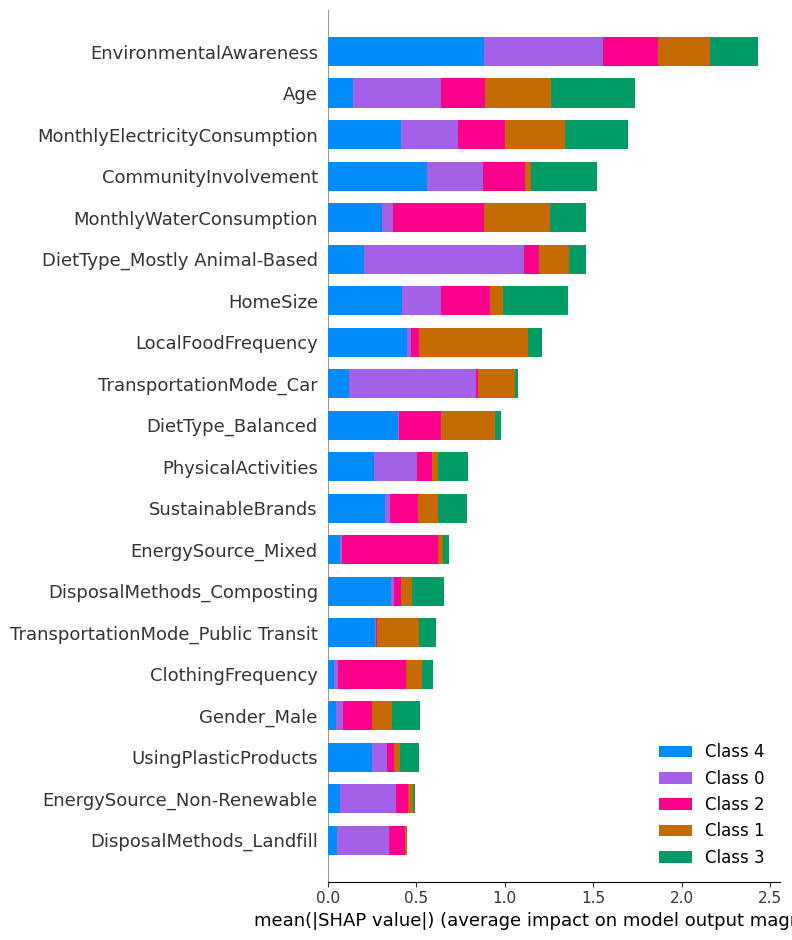

In [16]:
# handle these better with your own dataset, here we are simply dropping these
df = df.drop(['ParticipantID'], axis=1)

# Define features and target
X = df.drop("Rating", axis=1)

y = df['Rating']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# use GPU-enabled XGBoost Regressor
model = xgb.XGBClassifier(tree_method='gpu_hist', objective="multi:softproba", num_class=5)
# model = xgb.XGBClassifier(tree_method='gpu_hist', objective="binary:logistic", num_class=2)
model.fit(X_train, y_train)

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test, check_additivity=False)

print("shap_values.values.shape:", shap_values.values.shape)
# Typically (n_samples, n_classes, n_features) = (30, 3, 4) for Iris
print("X_test.shape:", X_test.shape)

shap.summary_plot(shap_values, X_test)

___

### More experimental additional SHAP visualizations

Combination of AI, documentation and Googling


--- Beeswarm for class 0 ---


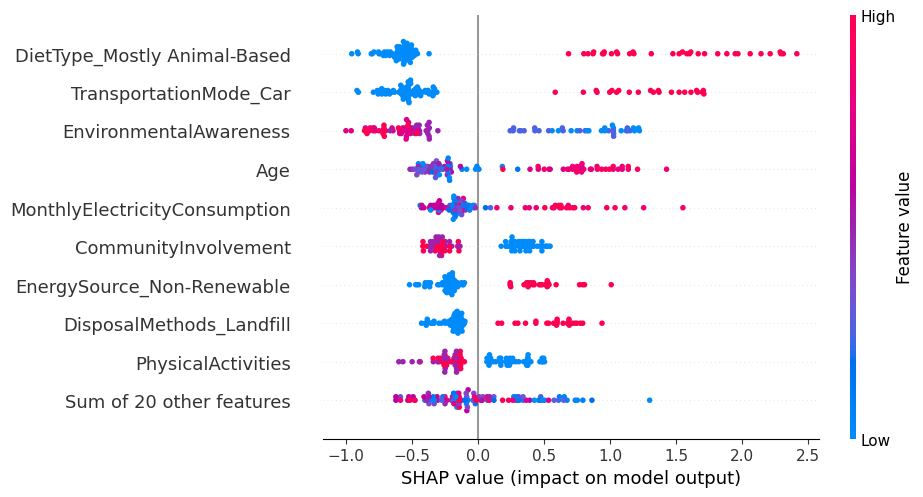


--- Beeswarm for class 1 ---


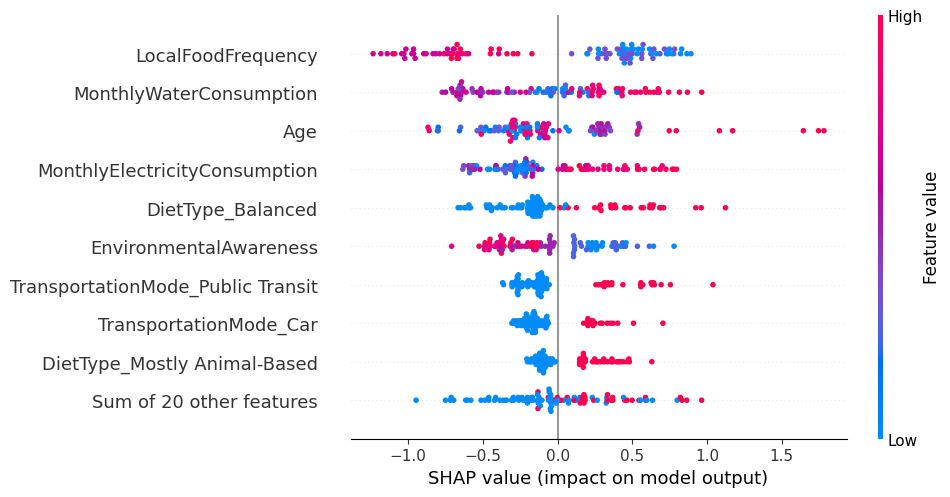


--- Beeswarm for class 2 ---


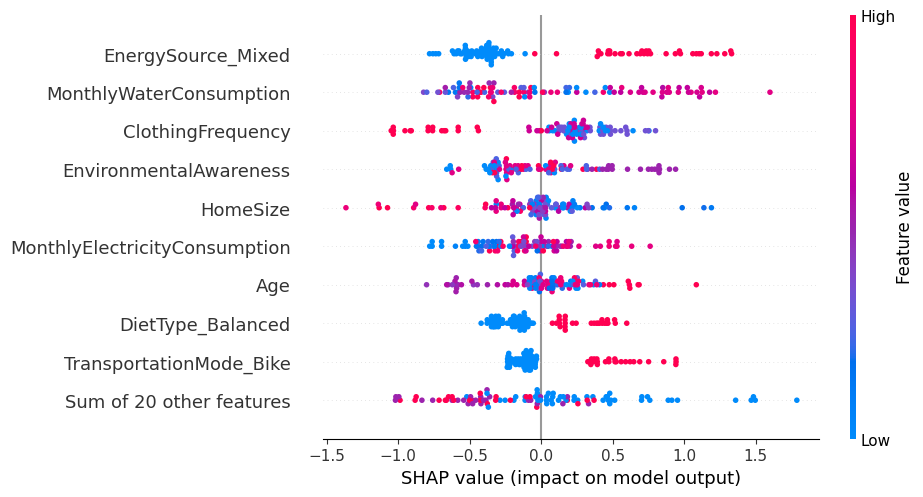


--- Beeswarm for class 3 ---


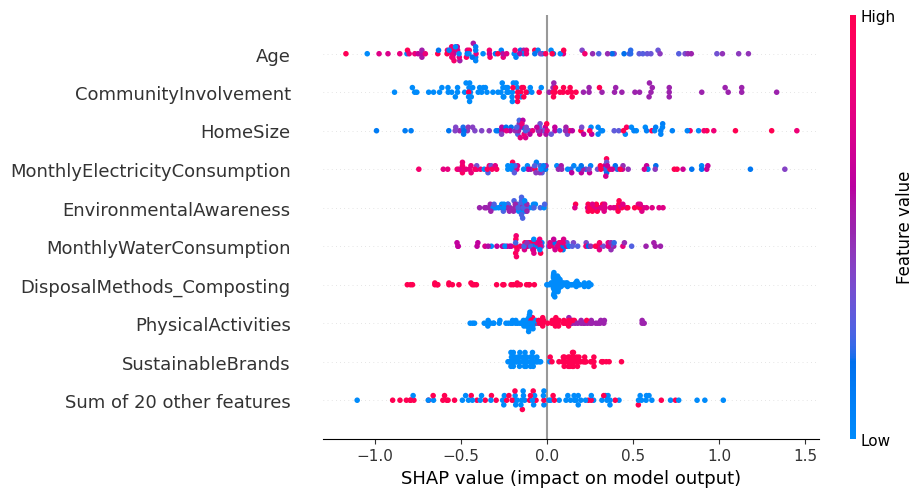


--- Beeswarm for class 4 ---


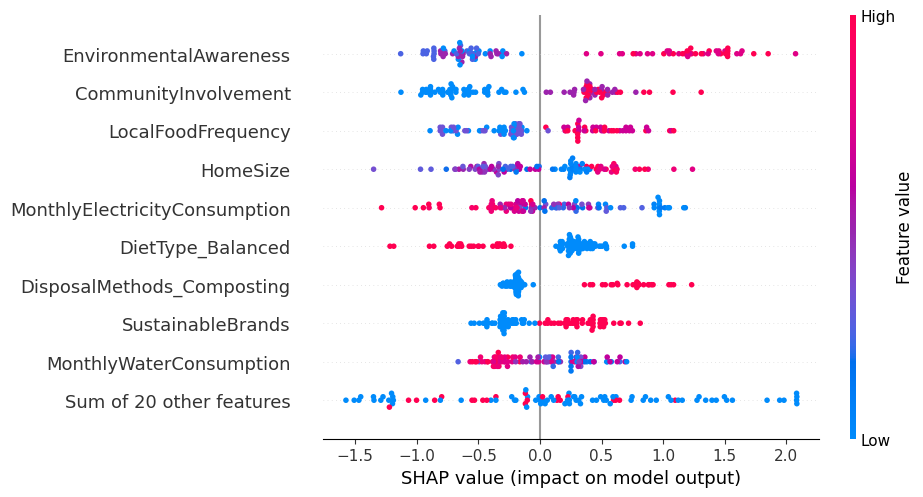

In [17]:
num_classes = shap_values.values.shape[1]
for class_idx in range(5):
    # Extract Explanation object for this class only
    shap_values_class = shap_values[..., class_idx]
    print(f"\n--- Beeswarm for class {class_idx} ---")
    shap.plots.beeswarm(shap_values_class)


--- Beeswarm for class 0 ---


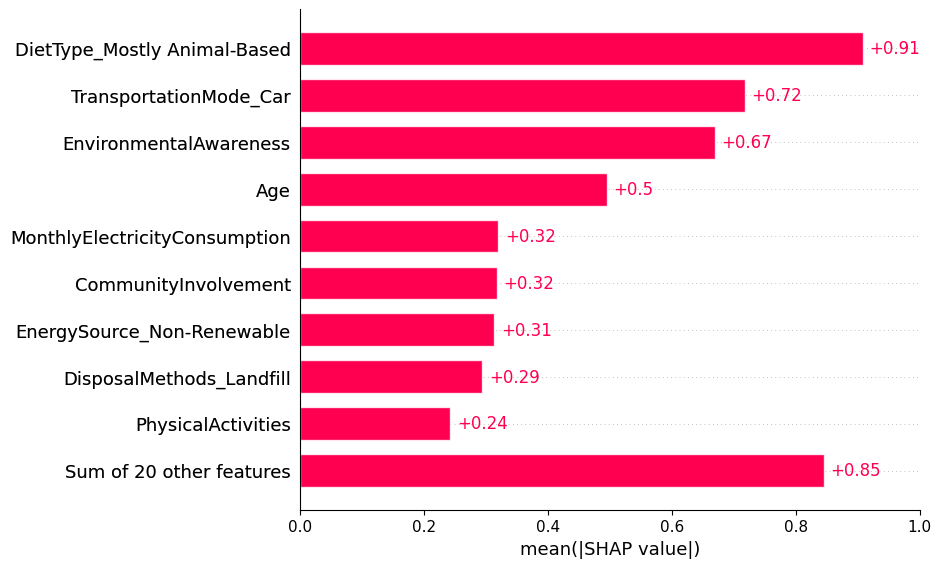


--- Beeswarm for class 1 ---


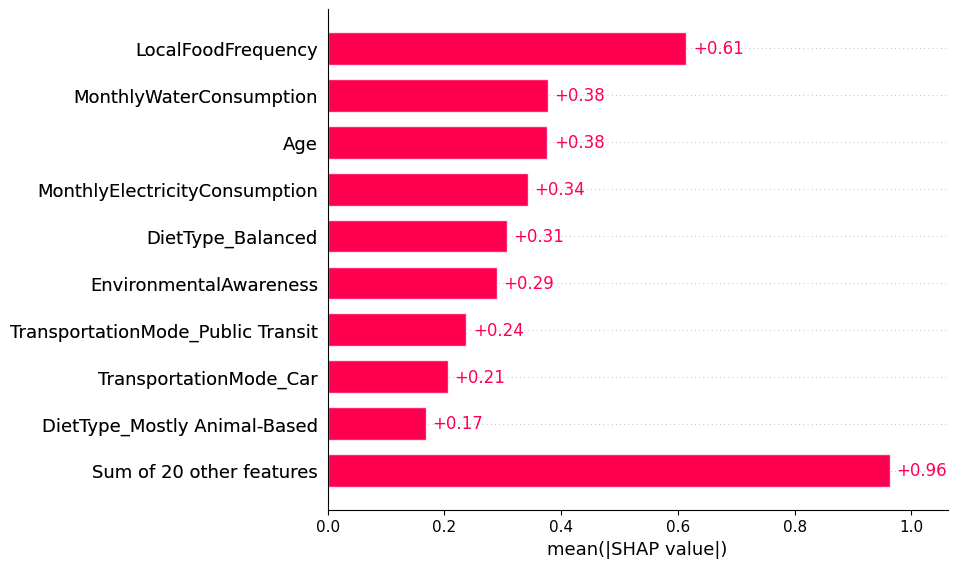


--- Beeswarm for class 2 ---


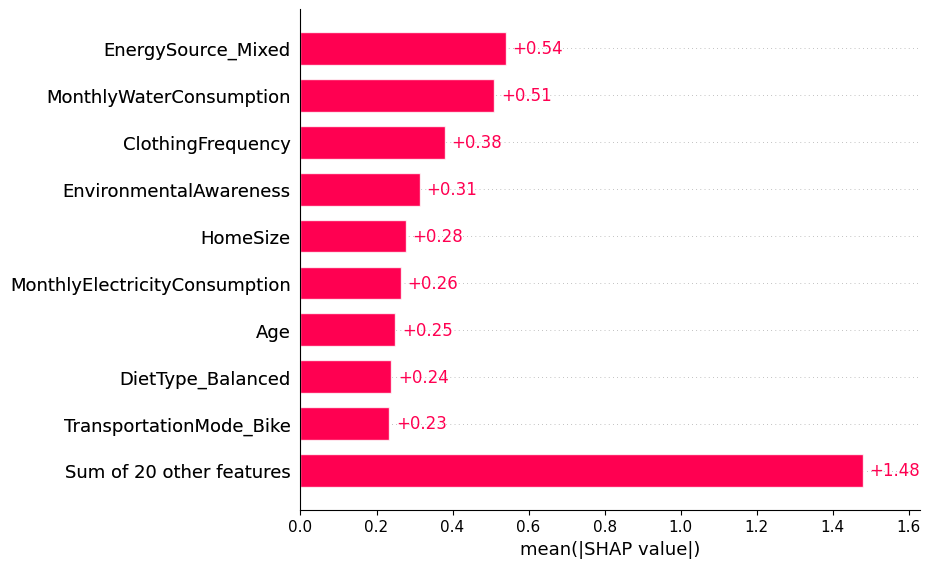


--- Beeswarm for class 3 ---


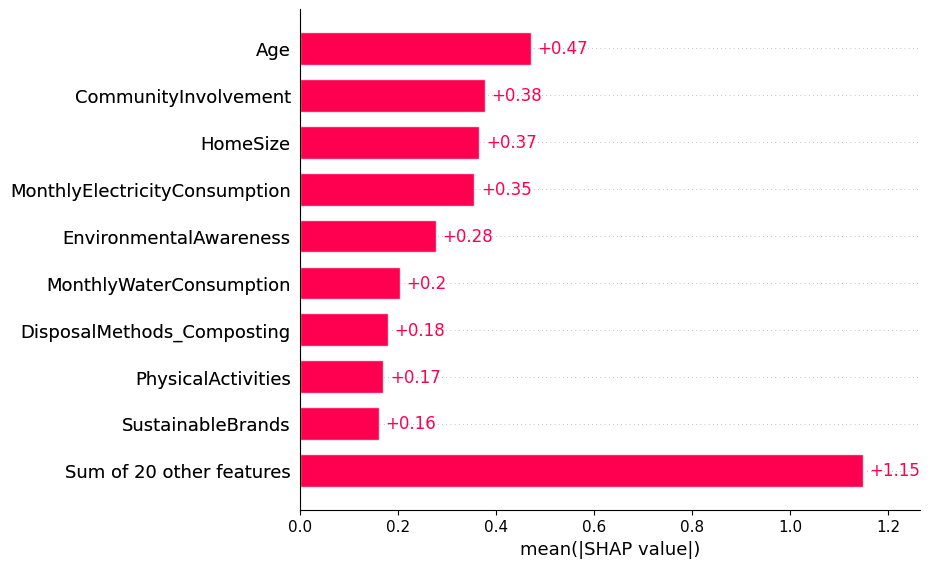


--- Beeswarm for class 4 ---


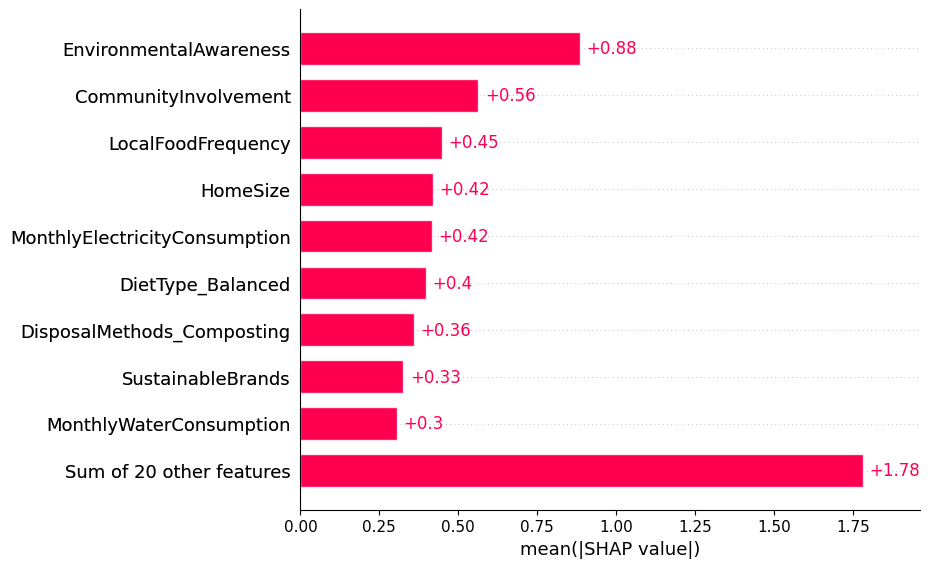

In [18]:
num_classes = shap_values.values.shape[1]
for class_idx in range(5):
    # Extract Explanation object for this class only
    shap_values_class = shap_values[..., class_idx]
    print(f"\n--- Beeswarm for class {class_idx} ---")
   
    shap.plots.bar(shap_values_class)

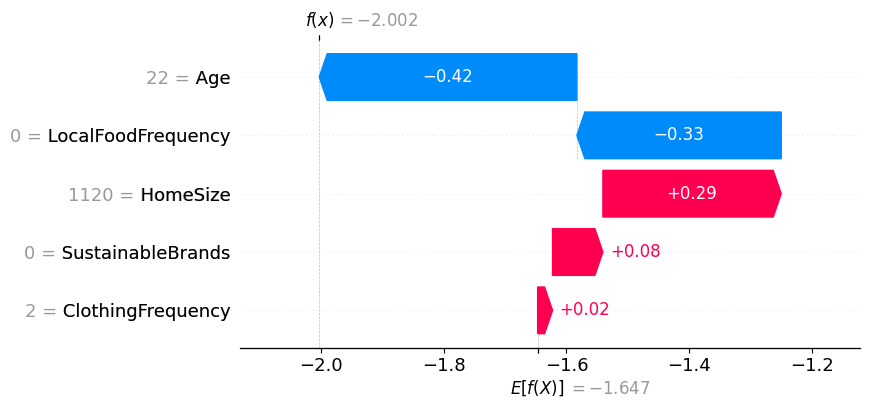

In [19]:
import shap

# Pick a sample index and class
sample_idx = 0
class_idx = 0

# Extract values & base_values explicitly
vals = shap_values.values[sample_idx, class_idx]
base_val = shap_values.base_values[sample_idx, class_idx]
data = shap_values.data[sample_idx]

# Construct a new Explanation object explicitly
single_exp = shap.Explanation(
    values=vals,
    base_values=base_val,
    data=data,
    feature_names=shap_values.feature_names
)

shap.plots.waterfall(single_exp)


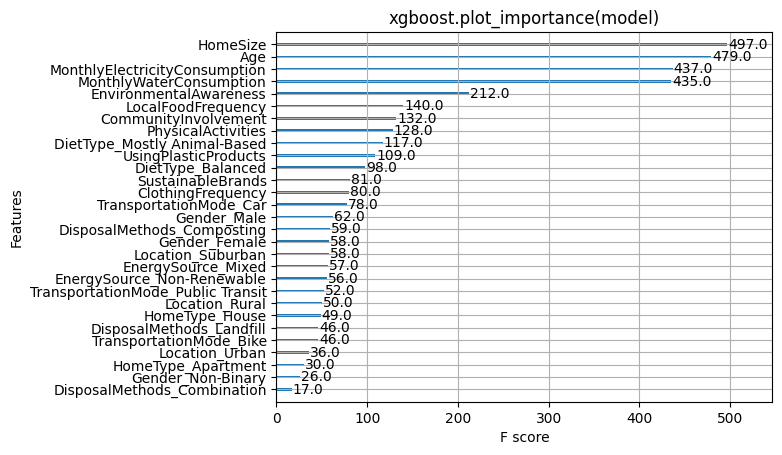

In [20]:
# XGBoost has a built-in importance feature too
xgb.plot_importance(model)
plt.title("xgboost.plot_importance(model)")
plt.show()

In [21]:
# Class index to explain (e.g., class 0)
class_idx = 0

shap.initjs()

shap.plots.force(
    base_value=shap_values.base_values[0][class_idx],
    shap_values=shap_values.values[0, :, class_idx],
    features=X_test.iloc[0],
    feature_names=list(X_test.columns)
)


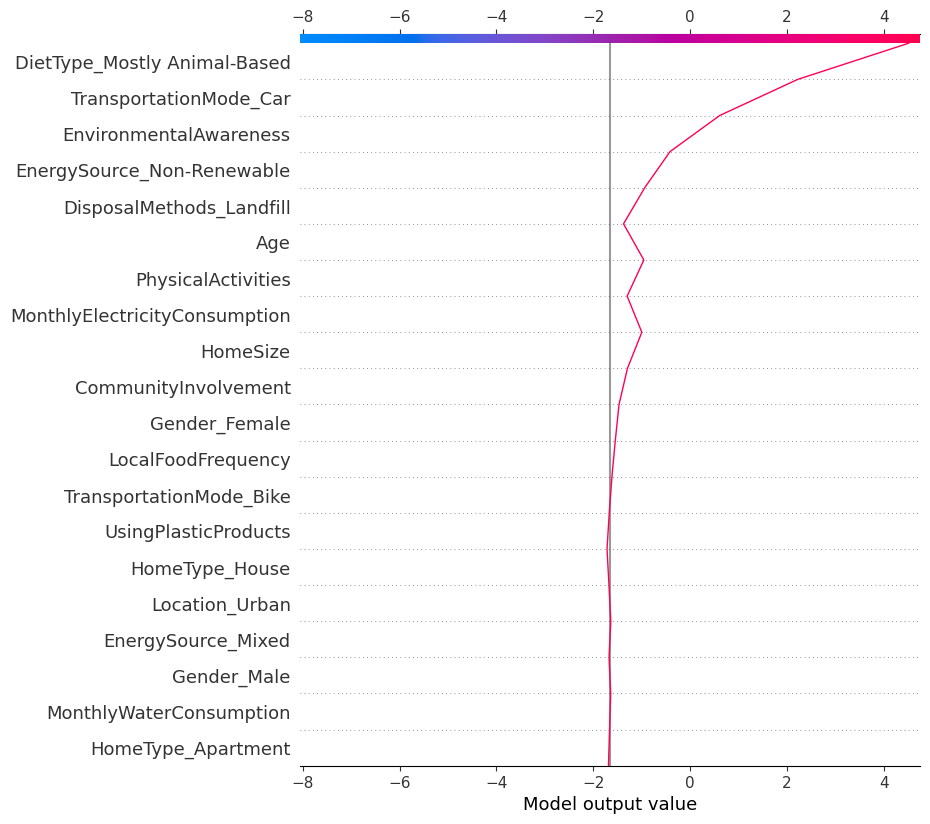

In [22]:
# Class index to explain (e.g., class 0)
class_idx = 0

shap.initjs()

shap.plots.decision(
    base_value=shap_values.base_values[0][class_idx],
    shap_values=shap_values.values[0, :, class_idx],
    feature_names=list(X_test.columns),
)


**This plot looks promising, but might have bugs, not thoroughly tested**

You have to be careful when using these, pay attention to which variables you compare AND WHICH TARGET CLASS ARE YOU COMPARING TO

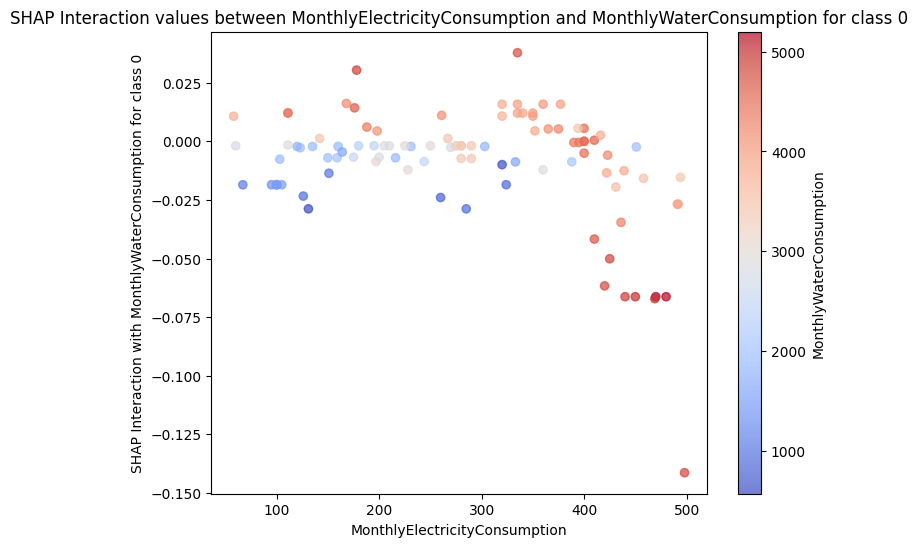

In [23]:
import matplotlib.pyplot as plt

feature_1 = 'MonthlyElectricityConsumption'
feature_2 = 'MonthlyWaterConsumption'

class_idx = 0  # class to inspect (0 to 4)

# # Use TreeExplainer specifically for XGBoost
explainer = shap.TreeExplainer(model)

feature_names = X_train.columns

# Subset X_test to these features to be sure of order
X_test_subset = X_test[feature_names]

# Get feature indices
i = feature_names.get_loc(feature_1)
j = feature_names.get_loc(feature_2)

shap_interaction_values = explainer.shap_interaction_values(X_test_subset)

# interaction array shape: (samples, feat1, feat2, classes)
# Pick class index on last axis
interaction_vals = shap_interaction_values[:, i, j, class_idx]

# Plot
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_test_subset[feature_1],  # x-axis: feature 1 values
    interaction_vals,          # y-axis: interaction SHAP values
    c=X_test_subset[feature_2],# color by feature 2 values
    cmap='coolwarm',
    alpha=0.7
)

plt.xlabel(feature_1)
plt.ylabel(f'SHAP Interaction with {feature_2} for class {class_idx}')
plt.colorbar(scatter, label=feature_2)
plt.title(f'SHAP Interaction values between {feature_1} and {feature_2} for class {class_idx}')
plt.show()


### Another version, dependence plot => basically interaction plot but in addition to interaction between variables, also their combined effect to target variable!

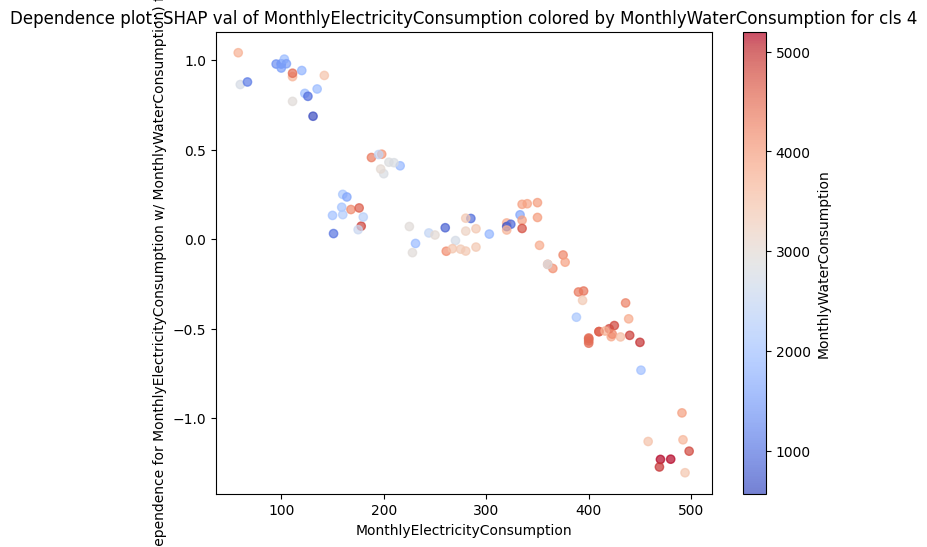

In [24]:
import matplotlib.pyplot as plt

class_idx = 4  # class to inspect (0 to 4)

# Indices of features
i = feature_names.get_loc(feature_1)
j = feature_names.get_loc(feature_2)

# Extract SHAP interaction values for class
interaction_values = shap_interaction_values[:, i, j, class_idx]

# Extract main effect SHAP values for feature_1
main_effect_values = shap_interaction_values[:, i, i, class_idx]

# Total SHAP value for feature_1 including interaction with feature_2
shap_values_feature_1 = main_effect_values + interaction_values

# Plot dependence plot
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_test_subset[feature_1],      # x-axis: feature 1 values
    shap_values_feature_1,         # y-axis: SHAP value for feature 1 + interaction
    c=X_test_subset[feature_2],    # color by feature 2 values
    cmap='coolwarm',
    alpha=0.7
)

plt.xlabel(feature_1)
plt.ylabel(f'SHAP dependence for {feature_1} w/ {feature_2}) for class {class_idx}')
plt.colorbar(scatter, label=feature_2)
plt.title(f'Dependence plot: SHAP val of {feature_1} colored by {feature_2} for cls {class_idx}')
plt.show()
